In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/nextgen_nlp_final")
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

NER_INPUT_PATH = ARTIFACTS_DIR / "ner_input_articles.parquet"

df_impact = pd.read_parquet(NER_INPUT_PATH)

print("Shape:", df_impact.shape)
df_impact.head()

Shape: (33765, 6)


,date,title_clean,clean_text,topic,topic_name,industry_label
0,2024-03-13 00:00:00+00:00,Best AI Prompts for Business Risk Management,ManagementPrompt: Identify and prioritize pote...,4,AI cybersecurity,Cybersecurity
1,2023-07-26 00:00:00+00:00,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,"July 26, 2023 Finance Bullfrog AI Holdings Inc...",0,AI chips and GPUs,AI Infrastructure
2,2025-01-17 00:00:00+00:00,4 Principles to Help Federal Agencies Adopt AI...,"Source: SolarWinds, “Navigating the AI Revolut...",4,AI cybersecurity,Cybersecurity
3,2024-02-13 00:00:00+00:00,2 Artificial Intelligence (AI) Stocks to Buy a...,"February 13, 2024 at 9:13 AM·4 min readArtific...",0,AI chips and GPUs,AI Infrastructure
4,2022-11-09 00:00:00+00:00,Silicon Photonics Market to Present Revenue Op...,"November 9, 2022, 9:02 AM·5 min readSkyQuest T...",0,AI chips and GPUs,AI Infrastructure


In [4]:
IMPACT_KEYWORDS = {

    "automation": [
        "automate", "automated", "automation", "fully automated",
        "autonomously", "autonomous processing", "machine-led",
        "replace manual work", "replace human work", "replace workers",
        "replace staff", "reduce headcount", "eliminate routine tasks",
        "task automation", "document automation", "underwriting automation",
        "decision automation", "robotic process automation", "rpa",
        "self-service", "without human intervention"
    ],

    "augmentation": [
        "augment", "augmentation", "assist", "assistance",
        "support workers", "support employees", "decision support",
        "copilot", "co-pilot", "assistant", "ai assistant",
        "human in the loop", "human-in-the-loop", "collaborate with",
        "enhance human", "improve clinician performance",
        "recommendation engine", "advisory tool", "decision aid",
        "support clinicians", "support teachers", "support developers"
    ],

    "workflow_redesign": [
        "workflow redesign", "workflow transformation", "workflow optimization",
        "workflow automation", "business process redesign", "business process transformation",
        "process redesign", "process transformation", "process optimization",
        "operational redesign", "operational transformation",
        "streamline operations", "streamline workflow",
        "integrated workflow", "embedded into workflow",
        "digital transformation", "reengineer processes", "re-engineer processes",
        "change how work is done", "reshape operations"
    ],

    "cost_reduction": [
        "reduce cost", "reduce costs", "cut cost", "cut costs",
        "lower cost", "lower costs", "cost reduction", "cost savings",
        "save money", "saving money", "reduce spending", "lower spending",
        "operational savings", "efficiency savings", "labor savings",
        "lower labor costs", "decrease expenses", "reduced overhead",
        "improve margins", "margin improvement"
    ],

    "productivity_gain": [
        "productivity", "increase productivity", "boost productivity",
        "improve efficiency", "increase efficiency", "greater efficiency",
        "faster", "faster turnaround", "speed up", "speeds up",
        "accelerate", "accelerates", "shorten turnaround",
        "reduce turnaround time", "save time", "time savings",
        "handle more work", "scale output", "higher throughput",
        "fewer bottlenecks", "improve performance"
    ],

    "risk_or_disruption": [
        "job loss", "job losses", "layoffs", "workforce reduction",
        "displace workers", "worker displacement", "disruption",
        "operational risk", "compliance risk", "bias", "hallucination",
        "safety concern", "security risk", "cyber risk",
        "ethical concern", "governance risk", "regulatory risk",
        "uncertainty", "hard to say", "unclear impact", "mixed impact",
        "unintended consequences", "threat to jobs", "replace jobs"
    ]
}

In [5]:
TECHNOLOGY_KEYWORDS = {
    "llm": [
        "large language model", "large language models",
        "llm", "llms", "foundation model", "foundation models",
        "generative ai", "genai", "language model"
    ],
    "computer_vision": [
        "computer vision", "image recognition", "image analysis",
        "vision model", "medical imaging", "object detection",
        "visual inspection"
    ],
    "predictive_analytics": [
        "predictive analytics", "prediction model", "forecasting",
        "risk scoring", "risk model", "scoring model"
    ],
    "decision_support_system": [
        "decision support", "recommendation engine", "clinical decision support",
        "advisory system", "decision engine"
    ],
    "automation_platform": [
        "robotic process automation", "rpa", "workflow automation",
        "process automation", "orchestration"
    ],
    "chatbot_or_assistant": [
        "chatbot", "virtual assistant", "ai assistant", "copilot", "co-pilot"
    ]
}

In [6]:
def detect_impact_modes(text, keyword_dict=IMPACT_KEYWORDS):
    text = str(text).lower()
    found_modes = []

    for mode, keywords in keyword_dict.items():
        for kw in keywords:
            if kw in text:
                found_modes.append(mode)
                break

    return sorted(set(found_modes))

In [7]:
def detect_technologies(text, keyword_dict=TECHNOLOGY_KEYWORDS):
    text = str(text).lower()
    found_tech = []

    for tech, keywords in keyword_dict.items():
        for kw in keywords:
            if kw in text:
                found_tech.append(tech)
                break

    return sorted(set(found_tech))

In [8]:
sample_texts = df_impact["clean_text"].sample(5, random_state=42)

for i, txt in enumerate(sample_texts, 1):
    print(f"\n========== SAMPLE {i} ==========")
    print(txt[:800])
    print("\nImpact modes:", detect_impact_modes(txt))
    print("Technologies:", detect_technologies(txt))


========== SAMPLE 1 ==========
June 5, 2025RELATED TOPICSAsia Press ReleaseLONDON, UNITED KINGDOM - Media OutReach Newswire - 5 June 2025 - Diginex Limited ("Diginex" or the "Company")(Nasdaq: DGNX), a leading provider of Sustainability RegTech solutions, today announced the signing of a Memorandum of Understanding ("MOU") for a cash and share acquisition of Resulticks, a globally recognized leader in real-time, AI-driven customer engagement and data management solutions. This strategic move will significantly enhance Diginex's capabilities in advanced data management and artificial intelligence, further solidifying its position as a pioneer in data-driven client solutions. The MOU values Resulticks at $2 billion which will be paid for in three tranches: $1.4 billion in Diginex ordinary shares valued at $72 per share an

Impact modes: ['automation']
Technologies: ['automation_platform']

========== SAMPLE 2 ==========
September 2, 2024 /EINPresswire / -- In a groundbreaking move poise

In [9]:
df_impact["impact_modes"] = df_impact["clean_text"].apply(detect_impact_modes)
df_impact["technologies"] = df_impact["clean_text"].apply(detect_technologies)

df_impact.head()

,date,title_clean,clean_text,topic,topic_name,industry_label,impact_modes,technologies
0,2024-03-13 00:00:00+00:00,Best AI Prompts for Business Risk Management,ManagementPrompt: Identify and prioritize pote...,4,AI cybersecurity,Cybersecurity,"[augmentation, automation, productivity_gain, ...",[]
1,2023-07-26 00:00:00+00:00,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,"July 26, 2023 Finance Bullfrog AI Holdings Inc...",0,AI chips and GPUs,AI Infrastructure,[],[]
2,2025-01-17 00:00:00+00:00,4 Principles to Help Federal Agencies Adopt AI...,"Source: SolarWinds, “Navigating the AI Revolut...",4,AI cybersecurity,Cybersecurity,"[productivity_gain, risk_or_disruption]",[llm]
3,2024-02-13 00:00:00+00:00,2 Artificial Intelligence (AI) Stocks to Buy a...,"February 13, 2024 at 9:13 AM·4 min readArtific...",0,AI chips and GPUs,AI Infrastructure,[productivity_gain],[llm]
4,2022-11-09 00:00:00+00:00,Silicon Photonics Market to Present Revenue Op...,"November 9, 2022, 9:02 AM·5 min readSkyQuest T...",0,AI chips and GPUs,AI Infrastructure,"[productivity_gain, risk_or_disruption]",[computer_vision]


In [10]:
df_impact_long = df_impact.explode("impact_modes")
df_impact_long = df_impact_long.dropna(subset=["impact_modes"]).copy()

print(df_impact_long.shape)
df_impact_long.head()

(42854, 8)


,date,title_clean,clean_text,topic,topic_name,industry_label,impact_modes,technologies
0,2024-03-13 00:00:00+00:00,Best AI Prompts for Business Risk Management,ManagementPrompt: Identify and prioritize pote...,4,AI cybersecurity,Cybersecurity,augmentation,[]
0,2024-03-13 00:00:00+00:00,Best AI Prompts for Business Risk Management,ManagementPrompt: Identify and prioritize pote...,4,AI cybersecurity,Cybersecurity,automation,[]
0,2024-03-13 00:00:00+00:00,Best AI Prompts for Business Risk Management,ManagementPrompt: Identify and prioritize pote...,4,AI cybersecurity,Cybersecurity,productivity_gain,[]
0,2024-03-13 00:00:00+00:00,Best AI Prompts for Business Risk Management,ManagementPrompt: Identify and prioritize pote...,4,AI cybersecurity,Cybersecurity,risk_or_disruption,[]
2,2025-01-17 00:00:00+00:00,4 Principles to Help Federal Agencies Adopt AI...,"Source: SolarWinds, “Navigating the AI Revolut...",4,AI cybersecurity,Cybersecurity,productivity_gain,[llm]


In [11]:
df_tech_long = df_impact.explode("technologies")
df_tech_long = df_tech_long.dropna(subset=["technologies"]).copy()

print(df_tech_long.shape)
df_tech_long.head()

(24910, 8)


,date,title_clean,clean_text,topic,topic_name,industry_label,impact_modes,technologies
2,2025-01-17 00:00:00+00:00,4 Principles to Help Federal Agencies Adopt AI...,"Source: SolarWinds, “Navigating the AI Revolut...",4,AI cybersecurity,Cybersecurity,"[productivity_gain, risk_or_disruption]",llm
3,2024-02-13 00:00:00+00:00,2 Artificial Intelligence (AI) Stocks to Buy a...,"February 13, 2024 at 9:13 AM·4 min readArtific...",0,AI chips and GPUs,AI Infrastructure,[productivity_gain],llm
4,2022-11-09 00:00:00+00:00,Silicon Photonics Market to Present Revenue Op...,"November 9, 2022, 9:02 AM·5 min readSkyQuest T...",0,AI chips and GPUs,AI Infrastructure,"[productivity_gain, risk_or_disruption]",computer_vision
9,2023-10-06 00:00:00+00:00,Why is private AI the next frontier for enterp...,Explore: private AI is the next frontier for e...,0,AI chips and GPUs,AI Infrastructure,[augmentation],llm
10,2024-12-11 00:00:00+00:00,Trinity Life Sciences Appoints Jonathan Jenkin...,"December 11, 2024 | 2 min read Twitter LinkedI...",1,AI in healthcare and medical imaging,Healthcare,[productivity_gain],predictive_analytics


In [12]:
industry_impact_counts = (
    df_impact_long
    .groupby(["industry_label", "impact_modes"])
    .size()
    .reset_index(name="count")
    .sort_values(["industry_label", "count"], ascending=[True, False])
)

industry_impact_counts.head(30)

,industry_label,impact_modes,count
4,AI Governance / Risk,risk_or_disruption,743
1,AI Governance / Risk,automation,647
0,AI Governance / Risk,augmentation,606
3,AI Governance / Risk,productivity_gain,533
2,AI Governance / Risk,cost_reduction,69
5,AI Governance / Risk,workflow_redesign,36
9,AI Infrastructure,productivity_gain,3296
6,AI Infrastructure,augmentation,2191
7,AI Infrastructure,automation,1913
10,AI Infrastructure,risk_or_disruption,1039


In [13]:
industry_tech_counts = (
    df_tech_long
    .groupby(["industry_label", "technologies"])
    .size()
    .reset_index(name="count")
    .sort_values(["industry_label", "count"], ascending=[True, False])
)

industry_tech_counts.head(30)

,industry_label,technologies,count
4,AI Governance / Risk,llm,907
1,AI Governance / Risk,chatbot_or_assistant,880
0,AI Governance / Risk,automation_platform,299
2,AI Governance / Risk,computer_vision,84
5,AI Governance / Risk,predictive_analytics,36
3,AI Governance / Risk,decision_support_system,19
10,AI Infrastructure,llm,2668
7,AI Infrastructure,chatbot_or_assistant,1268
6,AI Infrastructure,automation_platform,924
8,AI Infrastructure,computer_vision,423


In [14]:
IMPACT_ARTICLE_PATH = ARTIFACTS_DIR / "impact_article_level.parquet"
IMPACT_LONG_PATH = ARTIFACTS_DIR / "impact_modes_long.parquet"
TECH_LONG_PATH = ARTIFACTS_DIR / "technology_modes_long.parquet"

df_impact.to_parquet(IMPACT_ARTICLE_PATH, index=False)
df_impact_long.to_parquet(IMPACT_LONG_PATH, index=False)
df_tech_long.to_parquet(TECH_LONG_PATH, index=False)

print("Saved:", IMPACT_ARTICLE_PATH)
print("Saved:", IMPACT_LONG_PATH)
print("Saved:", TECH_LONG_PATH)

Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/impact_article_level.parquet
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/impact_modes_long.parquet
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/technology_modes_long.parquet


In [15]:
IMPACT_TABLE_PATH = ARTIFACTS_DIR / "industry_impact_counts.parquet"
TECH_TABLE_PATH = ARTIFACTS_DIR / "industry_technology_counts.parquet"

industry_impact_counts.to_parquet(IMPACT_TABLE_PATH, index=False)
industry_tech_counts.to_parquet(TECH_TABLE_PATH, index=False)

print("Saved:", IMPACT_TABLE_PATH)
print("Saved:", TECH_TABLE_PATH)

Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/industry_impact_counts.parquet
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/industry_technology_counts.parquet


In [16]:
industry_impact_counts.to_csv(ARTIFACTS_DIR / "industry_impact_counts.csv", index=False)
industry_tech_counts.to_csv(ARTIFACTS_DIR / "industry_technology_counts.csv", index=False)

In [17]:
impact_top = (
    industry_impact_counts
    .sort_values("count", ascending=False)
    .groupby("industry_label")
    .head(3)
)

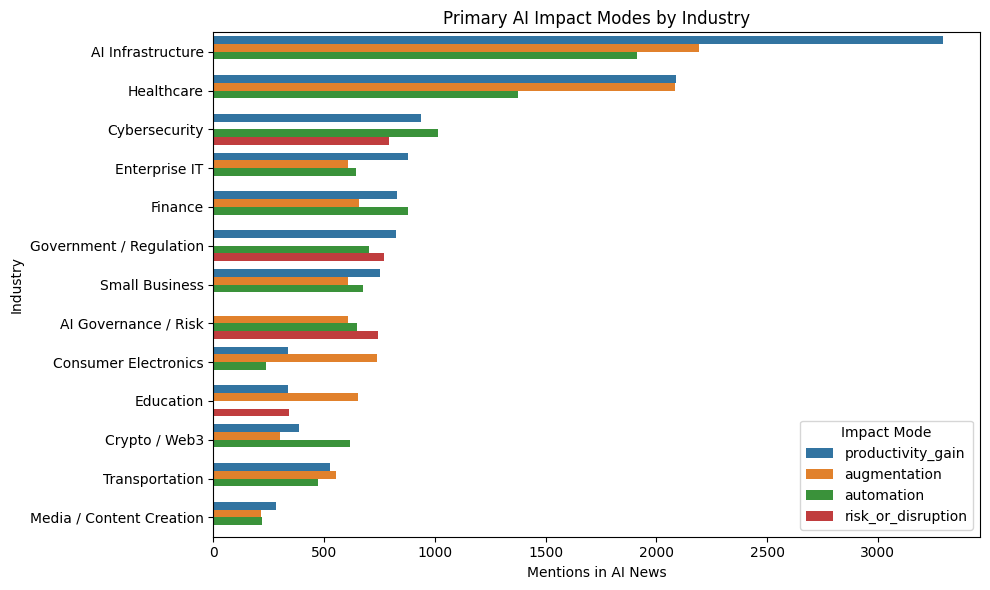

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=impact_top,
    x="count",
    y="industry_label",
    hue="impact_modes"
)

plt.title("Primary AI Impact Modes by Industry")

plt.xlabel("Mentions in AI News")
plt.ylabel("Industry")

plt.legend(title="Impact Mode")

plt.tight_layout()
plt.show()

In [19]:
tech_top = (
    industry_tech_counts
    .sort_values("count", ascending=False)
    .groupby("industry_label")
    .head(3)
)

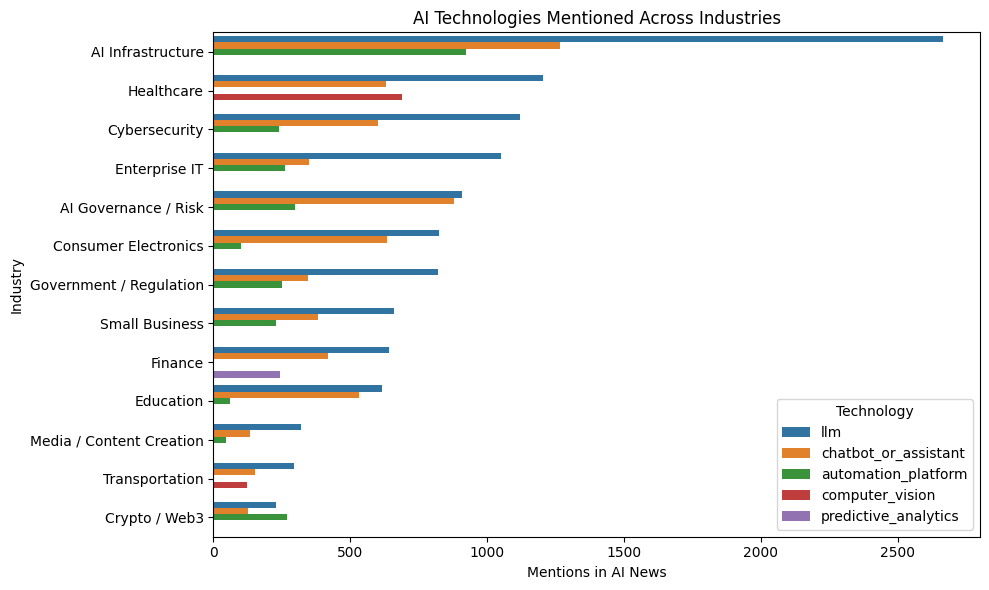

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tech_top,
    x="count",
    y="industry_label",
    hue="technologies"
)

plt.title("AI Technologies Mentioned Across Industries")

plt.xlabel("Mentions in AI News")
plt.ylabel("Industry")

plt.legend(title="Technology")

plt.tight_layout()
plt.show()

In [21]:
impact_summary = (
    industry_impact_counts
    .groupby("impact_modes")["count"]
    .sum()
    .reset_index()
    .sort_values("count", ascending=False)
)

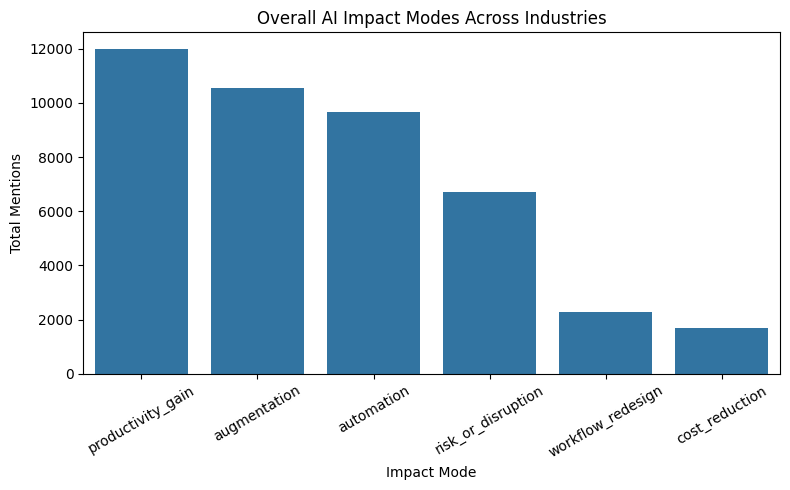

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=impact_summary,
    x="impact_modes",
    y="count"
)

plt.title("Overall AI Impact Modes Across Industries")

plt.xlabel("Impact Mode")
plt.ylabel("Total Mentions")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [23]:
heatmap_data = industry_tech_counts.pivot(
    index="industry_label",
    columns="technologies",
    values="count"
).fillna(0)

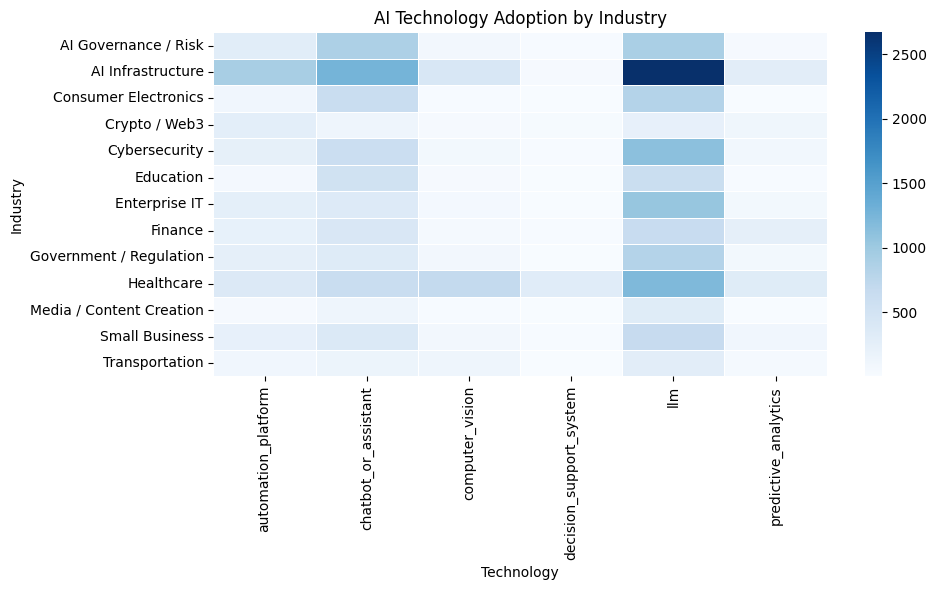

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.5
)

plt.title("AI Technology Adoption by Industry")

plt.xlabel("Technology")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

In [25]:
plt.savefig(ARTIFACTS_DIR / "impact_by_industry.png", dpi=300)

<Figure size 640x480 with 0 Axes>